# 07. Multiple Testing, False Discovery, and Research Risk

Once analysts stop asking one question and start asking ten, twenty, or fifty related questions, ordinary single-test intuition breaks down. A p-value of 0.04 may look persuasive when it is the only test on the table. It looks very different when it is the smallest value in a dashboard built from dozens of subgroup cuts, outcome variants, and exploratory filters.

We study that shift from a decision-science perspective. The issue is more than mathematical etiquette. Multiple testing changes the risk that an organization will chase noise, overstate evidence, or allocate resources to the wrong segment because one lucky comparison happened to pass a familiar threshold.

We will work through three layers of the problem:

1. how repeated testing inflates the probability of false alarms,
2. how Bonferroni, Holm, and Benjamini-Hochberg change a concrete segmented analysis,
3. how familywise-error and false-discovery targets differ in the kinds of risk they are willing to tolerate.


## Learning Objectives

After working through this lecture, you should be able to:

1. Explain why repeated testing inflates false-positive risk even when each single test uses level 0.05.
2. Define the familywise error rate (FWER) and the false discovery rate (FDR).
3. Compute and interpret Bonferroni, Holm, and Benjamini-Hochberg adjustments.
4. Explain why a method that controls FWER can still make a false discovery in a realized family of tests.
5. Distinguish confirmation-oriented procedures from discovery-oriented procedures.
6. Diagnose how a segmented product analysis can become misleading if multiplicity is ignored.
7. Compare long-run trade-offs among raw testing, FWER control, and FDR control.
8. Write a recommendation that separates confirmed findings from exploratory leads.


### Dataset and Experiment Design

We use two synthetic experiments. The first is an all-null dashboard in which a harmless change truly affects no segment, but the analyst runs many tests anyway. The unit of analysis there is the test family, not an individual customer or ticket. It isolates how false alarms accumulate when many null hypotheses are inspected.

The second experiment is a segmented rollout analysis. Each segment has an observed effect estimate, standard error, p-value, and hidden truth about whether the policy really helps. Some segments have real signal and others do not. Because this is a teaching simulation, the hidden truth lets us evaluate which discoveries are correct after different adjustment rules.

We want to make research risk visible. A business dashboard can invite many plausible cuts of the same data. Without a clear family definition and an error-control strategy, the analysis can turn random variation into a confident but fragile story.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 180)
np.random.seed(2026)


def bonferroni_adjust(p_values):
    """
    Apply the Bonferroni multiple-testing adjustment to a family of p-values.
    
    Parameters:
        p_values: Raw p-values from tests that belong to the same reporting family.
    
    Returns:
        A NumPy array of Bonferroni-adjusted p-values, clipped at 1.
    
    Idea:
        Multiply each p-value by the number of tests to protect against making even one false discovery in the family.
    """
    p_values = np.asarray(p_values, dtype=float)
    return np.minimum(len(p_values) * p_values, 1.0)


def holm_adjust(p_values):
    """
    Apply Holm's step-down familywise-error adjustment.
    
    Parameters:
        p_values: Raw p-values from one simultaneous testing family.
    
    Returns:
        A NumPy array of Holm-adjusted p-values in the original hypothesis order.
    
    Idea:
        Sort the p-values, apply increasingly less severe familywise-error thresholds, and then map the adjusted values back to the original segments.
    """
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    order = np.argsort(p_values)
    p_sorted = p_values[order]
    adjusted_sorted = np.maximum.accumulate((m - np.arange(m)) * p_sorted)
    adjusted_sorted = np.clip(adjusted_sorted, 0.0, 1.0)
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = adjusted_sorted
    return adjusted


def bh_adjust(p_values):
    """
    Apply the Benjamini-Hochberg false-discovery-rate adjustment.
    
    Parameters:
        p_values: Raw p-values from one discovery-oriented testing family.
    
    Returns:
        A NumPy array of BH-adjusted q-values in the original hypothesis order.
    
    Idea:
        Control the expected false-discovery proportion while allowing more discoveries than stricter familywise-error procedures.
    """
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    order = np.argsort(p_values)
    p_sorted = p_values[order]
    adjusted_sorted = (m / np.arange(1, m + 1)) * p_sorted
    adjusted_sorted = np.minimum.accumulate(adjusted_sorted[::-1])[::-1]
    adjusted_sorted = np.clip(adjusted_sorted, 0.0, 1.0)
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = adjusted_sorted
    return adjusted


def rejection_table(p_values, alpha=0.05):
    """
    Mark rejections under raw, Bonferroni, Holm, and Benjamini-Hochberg rules.
    
    Parameters:
        p_values: Raw p-values from the hypotheses being evaluated together.
        alpha: Target error-rate level used by the raw and adjusted decision rules.
    
    Returns:
        A dictionary whose values are boolean arrays indicating which hypotheses each rule rejects.
    
    Idea:
        Keep the p-value family fixed and show how the discovery list changes when the error target changes.
    """
    p_values = np.asarray(p_values, dtype=float)
    return {
        'raw': p_values <= alpha,
        'bonferroni': bonferroni_adjust(p_values) <= alpha,
        'holm': holm_adjust(p_values) <= alpha,
        'bh': bh_adjust(p_values) <= alpha,
    }


def simulate_all_null_dashboard(m_grid=(1, 5, 10, 20, 50), sims=4_000, alpha=0.05, seed=2026):
    """
    Simulate dashboards in which every tested null hypothesis is true.
    
    Parameters:
        m_grid: Numbers of simultaneous null tests to include in the false-alarm curve.
        sims: Number of simulated dashboards generated for each family size.
        alpha: Single-test or adjusted testing level used to define rejections.
        seed: Random seed used to make the simulation reproducible.
    
    Returns:
        A tuple with a family-size curve and a method-comparison table for the all-null setting.
    
    Idea:
        Show that a dashboard can manufacture false discoveries even when the underlying intervention has no effect anywhere.
    """
    rng = np.random.default_rng(seed)

    curve_rows = []
    for m in m_grid:
        p_matrix = rng.uniform(size=(sims, m))
        curve_rows.append(
            {
                'm_tests': m,
                'empirical_raw_fwer': (p_matrix.min(axis=1) < alpha).mean(),
                'formula_raw_fwer': 1 - (1 - alpha) ** m,
                'average_raw_false_positives': (p_matrix < alpha).sum(axis=1).mean(),
            }
        )

    compare_m = 20
    p_matrix = rng.uniform(size=(sims, compare_m))
    method_rows = []
    for method in ['raw', 'bonferroni', 'holm', 'bh']:
        family_rejections = []
        for p_values in p_matrix:
            family_rejections.append(rejection_table(p_values, alpha=alpha)[method])
        family_rejections = np.asarray(family_rejections)
        method_rows.append(
            {
                'method': method,
                'empirical_fwer': family_rejections.any(axis=1).mean(),
                'average_false_positives_per_family': family_rejections.sum(axis=1).mean(),
            }
        )

    return pd.DataFrame(curve_rows), pd.DataFrame(method_rows)


def build_segment_rollout(seed=2003):
    """
    Create a segmented rollout testing family with hidden true and null effects.
    
    Parameters:
        seed: Random seed used to make the synthetic segmented rollout reproducible.
    
    Returns:
        A pandas DataFrame with segment labels, true effects, observed effects, p-values, adjusted p-values, and rejection flags.
    
    Idea:
        Build a realistic subgroup-search example where some segments genuinely respond and others only look promising by chance.
    """
    rng = np.random.default_rng(seed)

    segments = [
        ('North America', 'Enterprise'),
        ('North America', 'SMB'),
        ('Europe', 'Enterprise'),
        ('Europe', 'SMB'),
        ('APAC', 'Enterprise'),
        ('APAC', 'SMB'),
        ('LatAm', 'Enterprise'),
        ('LatAm', 'SMB'),
        ('Public Sector', 'Large'),
        ('Public Sector', 'Small'),
        ('Marketplace', 'High-volume'),
        ('Marketplace', 'Long-tail'),
    ]

    true_effects = {
        ('North America', 'Enterprise'): -2.8,
        ('Europe', 'Enterprise'): -2.4,
        ('APAC', 'SMB'): -1.8,
        ('Marketplace', 'High-volume'): -2.1,
        ('Public Sector', 'Large'): -1.6,
    }

    rows = []
    for region, segment in segments:
        n_treat = rng.integers(140, 260)
        n_control = rng.integers(140, 260)
        baseline = rng.uniform(28, 40)
        sigma = rng.uniform(5.5, 8.5)
        true_effect = true_effects.get((region, segment), 0.0)

        control = rng.normal(baseline, sigma, size=n_control)
        treated = rng.normal(baseline + true_effect, sigma, size=n_treat)

        test = stats.ttest_ind(treated, control, equal_var=False)
        observed_effect = treated.mean() - control.mean()
        se = np.sqrt(treated.var(ddof=1) / n_treat + control.var(ddof=1) / n_control)
        ci_low = observed_effect - 1.96 * se
        ci_high = observed_effect + 1.96 * se

        rows.append(
            {
                'region': region,
                'segment': segment,
                'segment_label': f'{region} | {segment}',
                'n_treat': int(n_treat),
                'n_control': int(n_control),
                'true_effect_minutes': true_effect,
                'observed_effect_minutes': observed_effect,
                'p_value': test.pvalue,
                'ci_low': ci_low,
                'ci_high': ci_high,
            }
        )

    results = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
    results['p_bonferroni'] = bonferroni_adjust(results['p_value'])
    results['p_holm'] = holm_adjust(results['p_value'])
    results['p_bh'] = bh_adjust(results['p_value'])

    results['reject_raw'] = results['p_value'] <= 0.05
    results['reject_bonferroni'] = results['p_bonferroni'] <= 0.05
    results['reject_holm'] = results['p_holm'] <= 0.05
    results['reject_bh'] = results['p_bh'] <= 0.05

    results['decision_status'] = np.select(
        [
            results['reject_holm'],
            results['reject_bh'],
            results['reject_raw'],
        ],
        [
            'Confirmed under FWER control',
            'Discovery candidate under FDR control',
            'Raw p < 0.05 only',
        ],
        default='No statistical signal',
    )
    return results


def simulate_mixed_families(n_tests=40, n_signal=8, signal_strength=2.3, sims=1_200, alpha=0.05, seed=2027):
    """
    Simulate repeated testing families containing both real signals and null effects.
    
    Parameters:
        n_tests: Total number of hypotheses in each simulated family.
        n_signal: Number of hypotheses with genuine nonzero effects.
        signal_strength: Mean shift applied to the true-signal test statistics.
        sims: Number of repeated testing families to simulate.
        alpha: Error-rate target used by the raw and adjusted rejection rules.
        seed: Random seed used to make the operating-characteristic simulation reproducible.
    
    Returns:
        A pandas DataFrame summarizing average discoveries, true discoveries, false discoveries, familywise false alarms, and realized false-discovery proportions.
    
    Idea:
        Quantify the trade-off between protecting against false leads and recovering enough real signals to guide follow-up decisions.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for _ in range(sims):
        truth = np.array([1] * n_signal + [0] * (n_tests - n_signal))
        rng.shuffle(truth)

        z_scores = rng.normal(0, 1, size=n_tests) + truth * signal_strength
        p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))
        family_decisions = rejection_table(p_values, alpha=alpha)

        for method, rejected in family_decisions.items():
            discoveries = int(rejected.sum())
            false_discoveries = int(((truth == 0) & rejected).sum())
            true_discoveries = int(((truth == 1) & rejected).sum())
            rows.append(
                {
                    'method': method,
                    'discoveries': discoveries,
                    'false_discoveries': false_discoveries,
                    'true_discoveries': true_discoveries,
                    'any_false_discovery': int(false_discoveries > 0),
                    'realized_fdp': false_discoveries / discoveries if discoveries > 0 else 0.0,
                }
            )

    summary = (
        pd.DataFrame(rows)
        .groupby('method')
        .agg(
            average_discoveries=('discoveries', 'mean'),
            average_false_discoveries=('false_discoveries', 'mean'),
            average_true_discoveries=('true_discoveries', 'mean'),
            share_with_any_false_discovery=('any_false_discovery', 'mean'),
            mean_realized_false_discovery_proportion=('realized_fdp', 'mean'),
        )
        .reset_index()
    )
    return summary

## 1. Why Repeated Testing Changes the Problem

When one null hypothesis is tested at level $\alpha$, the probability of a false rejection is controlled at $\alpha$. But if an analyst runs $m$ independent null tests and then highlights whether **any** one of them looks significant, the relevant error probability becomes the **familywise error rate**

$$
\text{FWER} = P(V \ge 1),
$$

where $V$ is the number of false rejections in the family.

If all $m$ null hypotheses are true and the tests are independent, then the naive unadjusted familywise error becomes

$$
\text{FWER}_{\text{raw}} = 1 - (1 - \alpha)^m.
$$

This rises quickly with $m$. So the moment a dashboard contains many slices, the phrase "significant at 0.05" stops meaning what most people think it means.


## 2. Setup: The All-Null Dashboard Trap

Imagine a product team rolls out a harmless copy change that truly has **no effect** on any business segment. An analyst nevertheless checks 20 plausible cuts of the data: region, customer tier, queue type, acquisition channel, weekend versus weekday, and so on.

If each test is run at the ordinary 0.05 level and the smallest p-value is celebrated, the dashboard is almost guaranteed to manufacture a story eventually. This first example isolates that problem by simulating families in which every null hypothesis is actually true.


,m_tests,empirical_raw_fwer,formula_raw_fwer,average_raw_false_positives
0,1,0.045,0.050,0.045
1,5,0.219,0.226,0.242
2,10,0.411,0.401,0.516
3,20,0.659,0.642,1.031
4,50,0.927,0.923,2.516


,method,empirical_fwer,average_false_positives_per_family
0,raw,0.639750,1.001250
1,bonferroni,0.047750,0.048500
2,holm,0.047750,0.048500
3,bh,0.049250,0.053750


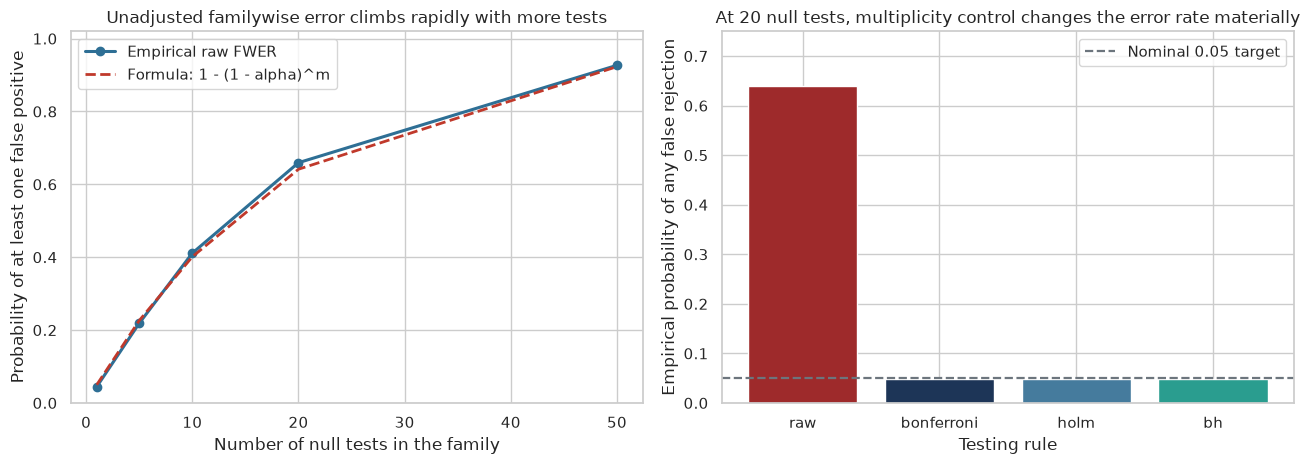

In [2]:
# Simulate dashboards with no real effects to show how raw false-alarm risk compounds across tests.
all_null_curve, all_null_methods = simulate_all_null_dashboard(
    m_grid=(1, 5, 10, 20, 50),
    sims=4_000,
    alpha=0.05,
    seed=2026,
)

smart_display(all_null_curve)
smart_display(all_null_methods)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

axes[0].plot(
    all_null_curve['m_tests'],
    all_null_curve['empirical_raw_fwer'],
    marker='o',
    linewidth=2.2,
    color='#2e6f95',
    label='Empirical raw FWER',
)
axes[0].plot(
    all_null_curve['m_tests'],
    all_null_curve['formula_raw_fwer'],
    linestyle='--',
    linewidth=2.0,
    color='#c0392b',
    label='Formula: 1 - (1 - alpha)^m',
)
axes[0].set_title('Unadjusted familywise error climbs rapidly with more tests')
axes[0].set_xlabel('Number of null tests in the family')
axes[0].set_ylabel('Probability of at least one false positive')
axes[0].set_ylim(0, 1.02)
axes[0].legend(frameon=True)

method_order = ['raw', 'bonferroni', 'holm', 'bh']
comparison = all_null_methods.set_index('method').loc[method_order].reset_index()
axes[1].bar(comparison['method'], comparison['empirical_fwer'], color=['#9e2a2b', '#1d3557', '#457b9d', '#2a9d8f'])
axes[1].axhline(0.05, color='#6c757d', linestyle='--', linewidth=1.6, label='Nominal 0.05 target')
axes[1].set_title('At 20 null tests, multiplicity control changes the error rate materially')
axes[1].set_xlabel('Testing rule')
axes[1].set_ylabel('Empirical probability of any false rejection')
axes[1].set_ylim(0, 0.75)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


The left panel makes the danger visible. With **20** independent null tests, the naive chance of at least one false alarm is roughly **64%**, not 5%. By **50** tests it is above **92%**.

The right panel shows the role of multiplicity adjustments. Bonferroni and Holm bring the familywise error rate back near the 0.05 target. Benjamini-Hochberg also sits near 0.05 in this all-null setting because when every null is true, controlling the FDR also controls the FWER.

This is the first core lesson: **a dashboard can look data-rich while actually being error-rich** if it quietly accumulates many unadjusted tests.

## 3. What the Common Error Targets Mean

Two error summaries dominate practical multiple testing.

The **familywise error rate** is

$$
\text{FWER} = P(V \ge 1),
$$

the probability of making even one false rejection in the family.

The **false discovery rate** is

$$
\text{FDR} = E\bigg[ \frac{V}{\max(R, 1)} \bigg],
$$

where $R$ is the total number of rejections. This is the expected proportion of false discoveries among all discoveries (Benjamini & Hochberg, 1995; Benjamini & Yekutieli, 2001).

The procedures here answer different operational questions:

- **Bonferroni**: control the chance of any false positive very conservatively by testing each hypothesis at $\alpha / m$.
- **Holm**: still controls FWER, but with a less conservative step-down rule.
- **Benjamini-Hochberg (BH)**: control the expected false discovery proportion, often allowing more discoveries than FWER-oriented procedures.

No method is universally best. The right choice depends on what a false positive would cost and whether the analysis is confirmatory or exploratory.


## 4. Setup: A Segmented Rollout Analysis

Now consider a more realistic case. A new routing policy is rolled out in customer support, and the analytics team tests whether average resolution time changed in **12** strategic segments.

Some segments genuinely benefit from the policy. Some do not. But the team does not know which is which. If it reports every raw p-value below 0.05 as a business insight, it risks promoting noise. If it is too conservative, it may miss segments where the policy really matters.

Because this is a teaching notebook, we retain the hidden truth in the synthetic data so we can see which conclusions were actually correct.


,method,discoveries,segments_flagged
0,Raw p < 0.05,6,"North America | Enterprise, APAC | SMB, Public Sector | Large, Europe | SMB, Europe | Enterprise, Marketplace | High-volume"
1,Bonferroni,3,"North America | Enterprise, APAC | SMB, Public Sector | Large"
2,Holm,4,"North America | Enterprise, APAC | SMB, Public Sector | Large, Europe | SMB"
3,Benjamini-Hochberg,6,"North America | Enterprise, APAC | SMB, Public Sector | Large, Europe | SMB, Europe | Enterprise, Marketplace | High-volume"


,segment_label,observed_effect_minutes,true_effect_minutes,p_value,p_bonferroni,p_holm,p_bh,decision_status
0,North America | Enterprise,-4.750887,-2.800000,0.000000,0.000000,0.000000,0.000000,Confirmed under FWER control
1,APAC | SMB,-2.549643,-1.800000,0.000005,0.000065,0.000059,0.000032,Confirmed under FWER control
2,Public Sector | Large,-3.459140,-1.600000,0.000021,0.000254,0.000211,0.000085,Confirmed under FWER control
3,Europe | SMB,2.191407,0.000000,0.005500,0.065997,0.049498,0.016499,Confirmed under FWER control
4,Europe | Enterprise,-1.999147,-2.400000,0.010797,0.129566,0.086378,0.025913,Discovery candidate under FDR control
5,Marketplace | High-volume,-1.764115,-2.100000,0.022245,0.266942,0.155716,0.044490,Discovery candidate under FDR control
6,APAC | Enterprise,0.967699,0.000000,0.139901,1.000000,0.839406,0.239830,No statistical signal
7,Marketplace | Long-tail,-0.896485,0.000000,0.235320,1.000000,1.000000,0.352980,No statistical signal
8,LatAm | Enterprise,-0.564744,0.000000,0.408988,1.000000,1.000000,0.545317,No statistical signal
9,North America | SMB,-0.605828,0.000000,0.476439,1.000000,1.000000,0.571727,No statistical signal


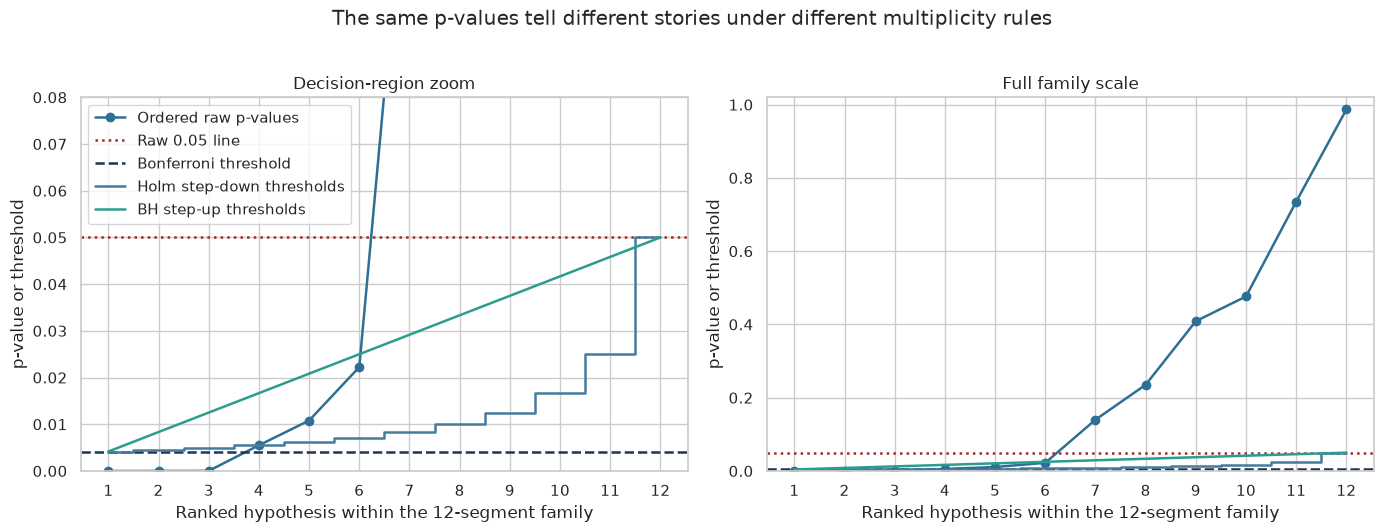

In [3]:
# Compare raw, FWER-controlled, and FDR-controlled discoveries in a segmented rollout family.
rollout = build_segment_rollout(seed=2003)

family_summary = pd.DataFrame(
    [
        {
            'method': 'Raw p < 0.05',
            'discoveries': int(rollout['reject_raw'].sum()),
            'segments_flagged': ', '.join(rollout.loc[rollout['reject_raw'], 'segment_label']),
        },
        {
            'method': 'Bonferroni',
            'discoveries': int(rollout['reject_bonferroni'].sum()),
            'segments_flagged': ', '.join(rollout.loc[rollout['reject_bonferroni'], 'segment_label']),
        },
        {
            'method': 'Holm',
            'discoveries': int(rollout['reject_holm'].sum()),
            'segments_flagged': ', '.join(rollout.loc[rollout['reject_holm'], 'segment_label']),
        },
        {
            'method': 'Benjamini-Hochberg',
            'discoveries': int(rollout['reject_bh'].sum()),
            'segments_flagged': ', '.join(rollout.loc[rollout['reject_bh'], 'segment_label']),
        },
    ]
)
smart_display(family_summary)

display_columns = [
    'segment_label',
    'observed_effect_minutes',
    'true_effect_minutes',
    'p_value',
    'p_bonferroni',
    'p_holm',
    'p_bh',
    'decision_status',
]
smart_display(rollout[display_columns])

ordered = rollout.sort_values('p_value').reset_index(drop=True)
m_tests = len(ordered)
ranks = np.arange(1, m_tests + 1)
holm_thresholds = 0.05 / (m_tests - ranks + 1)
bh_thresholds = 0.05 * ranks / m_tests

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2), sharex=True)

for ax in axes:
    ax.plot(ranks, ordered['p_value'], marker='o', linewidth=1.8, color='#2e6f95', label='Ordered raw p-values')
    ax.axhline(0.05, color='#9e2a2b', linestyle=':', linewidth=1.8, label='Raw 0.05 line')
    ax.axhline(0.05 / m_tests, color='#1d3557', linestyle='--', linewidth=1.8, label='Bonferroni threshold')
    ax.step(ranks, holm_thresholds, where='mid', color='#457b9d', linewidth=1.8, label='Holm step-down thresholds')
    ax.plot(ranks, bh_thresholds, color='#2a9d8f', linewidth=1.8, label='BH step-up thresholds')
    ax.set_xticks(ranks)
    ax.set_xlabel('Ranked hypothesis within the 12-segment family')
    ax.set_ylabel('p-value or threshold')

axes[0].set_title('Decision-region zoom')
axes[0].set_ylim(0, 0.08)
axes[0].legend(frameon=True, loc='upper left')

axes[1].set_title('Full family scale')
axes[1].set_ylim(0, 1.02)

fig.suptitle('The same p-values tell different stories under different multiplicity rules', y=1.02)
plt.tight_layout()
plt.show()


This realized family is instructive because the methods disagree in a way that matters.

- The raw analysis flags **6** segments.
- Bonferroni keeps only **3**.
- Holm keeps **4**.
- BH keeps **6**.

The hidden truth reveals why that matters. One segment with **no true effect** still lands below 0.05 by chance. In this realized family, that false lead survives the raw rule, **Holm**, and BH, while Bonferroni excludes it. At the same time, Holm drops some genuine but weaker signals that BH retains. In other words, no method is magically immune to bad luck in one dataset, and more conservative control can still trade away real discoveries.

That is the second core lesson: **error control is a long-run guarantee, not a promise that every realized discovery list is perfectly correct**.

## 5. Long-Run Trade-Offs in a Mixed-Signal World

A single realized family can be unlucky. To understand the procedures better, we should repeat the exercise many times.

In the next simulation, each family contains **40** tests, of which **8** correspond to real signals and **32** are null. We summarize what each method tends to do across many repeated families:

- how many total discoveries it makes,
- how many of those discoveries are true,
- how many are false,
- how often a family contains at least one false discovery,
- and the average realized false-discovery proportion.

This is where the philosophical split becomes operational. FWER methods protect strongly against any false alarm. BH aims for a low **proportion** of false alarms while recovering more true signals.


,method,average_discoveries,average_false_discoveries,average_true_discoveries,share_with_any_false_discovery,mean_realized_false_discovery_proportion
0,raw,6.586667,1.585833,5.000833,0.810000,0.227402
1,bonferroni,1.433333,0.044167,1.389167,0.044167,0.027458
2,holm,1.457500,0.047500,1.410000,0.047500,0.028639
3,bh,2.290833,0.135000,2.155833,0.124167,0.039052


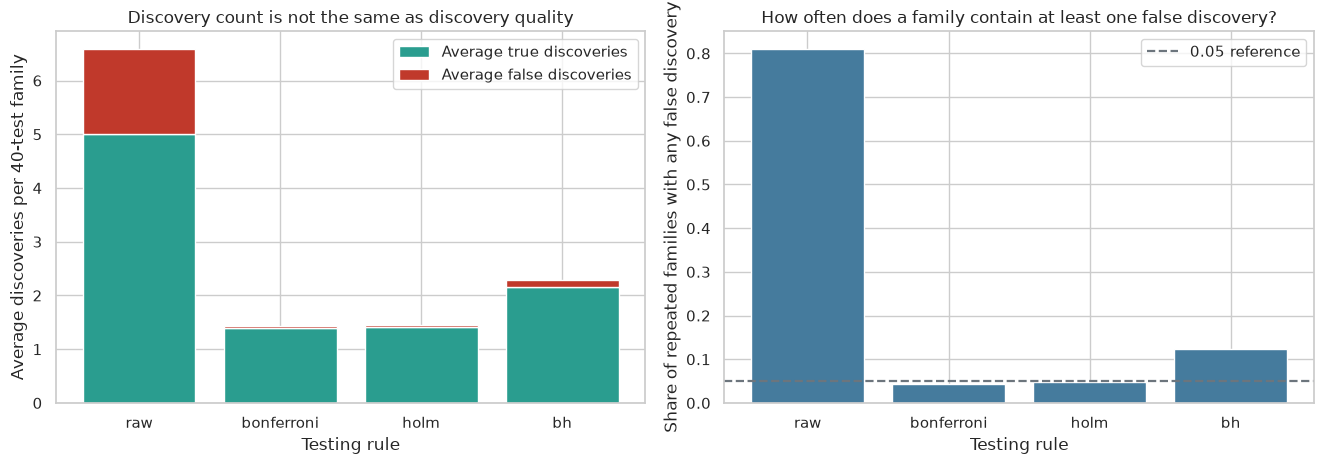

In [4]:
# Estimate long-run discovery quality when each family mixes true signals with null hypotheses.
repeated_summary = simulate_mixed_families(
    n_tests=40,
    n_signal=8,
    signal_strength=2.3,
    sims=1_200,
    alpha=0.05,
    seed=2027,
)

method_order = ['raw', 'bonferroni', 'holm', 'bh']
repeated_summary['method'] = pd.Categorical(repeated_summary['method'], categories=method_order, ordered=True)
repeated_summary = repeated_summary.sort_values('method').reset_index(drop=True)
smart_display(repeated_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

axes[0].bar(
    repeated_summary['method'],
    repeated_summary['average_true_discoveries'],
    color='#2a9d8f',
    label='Average true discoveries',
)
axes[0].bar(
    repeated_summary['method'],
    repeated_summary['average_false_discoveries'],
    bottom=repeated_summary['average_true_discoveries'],
    color='#c0392b',
    label='Average false discoveries',
)
axes[0].set_title('Discovery count is not the same as discovery quality')
axes[0].set_xlabel('Testing rule')
axes[0].set_ylabel('Average discoveries per 40-test family')
axes[0].legend(frameon=True)

axes[1].bar(repeated_summary['method'], repeated_summary['share_with_any_false_discovery'], color='#457b9d')
axes[1].set_title('How often does a family contain at least one false discovery?')
axes[1].set_xlabel('Testing rule')
axes[1].set_ylabel('Share of repeated families with any false discovery')
axes[1].axhline(0.05, color='#6c757d', linestyle='--', linewidth=1.6, label='0.05 reference')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


The repeated simulation shows the trade-off clearly.

- The **raw** rule finds the most real signals, but it also drags along many false ones and produces at least one false discovery in the vast majority of families.
- **Bonferroni** and **Holm** sharply reduce false alarms, but they also recover fewer true signals.
- **BH** typically finds substantially more true signals than the FWER methods while keeping the **average false-discovery proportion** low.

This is exactly why FDR control became attractive in high-dimensional discovery work (Benjamini & Hochberg, 1995; Benjamini, 2010). But the same result also explains why BH is not the right default for every decision. If even one false positive would be very expensive, a familywise-error target may still be the better operational choice.

In [5]:
# Separate confirmation-oriented discoveries from exploratory leads for the decision memo.
confirmed_segments = rollout.loc[rollout['reject_holm'], 'segment_label'].tolist()
exploratory_segments = rollout.loc[rollout['reject_bh'] & ~rollout['reject_holm'], 'segment_label'].tolist()
raw_only_segments = rollout.loc[rollout['reject_raw'] & ~rollout['reject_bh'], 'segment_label'].tolist()

memo = f"""
### Decision Memo

**Recommendation:** Separate this analysis into a **confirmation list** and a **discovery list** before turning one adjusted table into a binary verdict.

**Confirmed under familywise-error control:** {', '.join(confirmed_segments) if confirmed_segments else 'None'}.

**Additional discovery-oriented leads under BH but not Holm:** {', '.join(exploratory_segments) if exploratory_segments else 'None'}.

**Segments that would have looked significant under raw testing but do not survive BH:** {', '.join(raw_only_segments) if raw_only_segments else 'None'}.

**Interpretation:** The family contains enough simultaneous questions that raw p-values alone are not an acceptable basis for operational action. Holm offers a defensible confirmation list when the organization wants to keep the chance of any mistaken launch decision low, while BH is useful for prioritizing follow-up learning. In this synthetic notebook, the hidden truth also reminds us that even a Holm-confirmed list can still contain a false lead in one realized family.

**Actionable next step:** Use the Holm-confirmed segments for immediate resource allocation or stakeholder claims, and treat the BH-only segments as preregistered follow-up targets for the next experiment or quarter's validation study.
"""

display(Markdown(memo))



### Decision Memo

**Recommendation:** Separate this analysis into a **confirmation list** and a **discovery list** before turning one adjusted table into a binary verdict.

**Confirmed under familywise-error control:** North America | Enterprise, APAC | SMB, Public Sector | Large, Europe | SMB.

**Additional discovery-oriented leads under BH but not Holm:** Europe | Enterprise, Marketplace | High-volume.

**Segments that would have looked significant under raw testing but do not survive BH:** None.

**Interpretation:** The family contains enough simultaneous questions that raw p-values alone are not an acceptable basis for operational action. Holm offers a defensible confirmation list when the organization wants to keep the chance of any mistaken launch decision low, while BH is useful for prioritizing follow-up learning. In this synthetic notebook, the hidden truth also reminds us that even a Holm-confirmed list can still contain a false lead in one realized family.

**Actionable next step:** Use the Holm-confirmed segments for immediate resource allocation or stakeholder claims, and treat the BH-only segments as preregistered follow-up targets for the next experiment or quarter's validation study.


The confirmed-segment table is the handoff object. It separates exploratory hints from segments that survive a stated multiplicity rule. That distinction is what keeps a dashboard scan from turning into a collection of overconfident claims.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Segment Searches in RAND HIE

Multiple testing risk appears whenever analysts search many slices of the same dataset. RAND HIE is a good real-data companion because it contains utilization outcomes along with health-status and limitation indicators that can define subgroups.

The companion tests the free-care versus cost-sharing visit difference across several health-status and physical-limitation subgroups. The outcome is outpatient physician visits (`mdvis`), and the grouping is based on `lncoins`. Each subgroup test may be reasonable by itself, but the family of tests creates a reporting problem.

The experiment is intentionally simple: run a family of related tests and compare raw and adjusted discoveries. The purpose is not to publish a subgroup analysis of RAND HIE. The purpose is to show how quickly false-discovery risk appears when a real dataset invites many plausible cuts. A responsible report should distinguish confirmatory claims from exploratory leads.

For clarity, the unit of reporting is a subgroup-level test built from person-period records. The outcome is outpatient visit count, and the experiment repeats related subgroup contrasts to show how the family of tests changes research risk.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,segment,n,difference,raw_p_value,bh_q_value,bh_selected,bonferroni_selected
0,"Excellent, No physical limitation",10394,0.480000,0.000000,0.000000,True,True
1,"Excellent, Physical limitation",625,1.799200,0.000000,0.000000,True,True
2,"Good, No physical limitation",6266,0.503900,0.000000,0.000000,True,True
6,"Poor, No physical limitation",120,2.108400,0.006600,0.011300,True,False
5,"Fair, Physical limitation",537,1.736800,0.007100,0.011300,True,False
3,"Good, Physical limitation",1043,0.856500,0.042700,0.056900,False,False
7,"Poor, Physical limitation",182,-2.116000,0.113400,0.129600,False,False
4,"Fair, No physical limitation",1023,0.093800,0.734500,0.734500,False,False


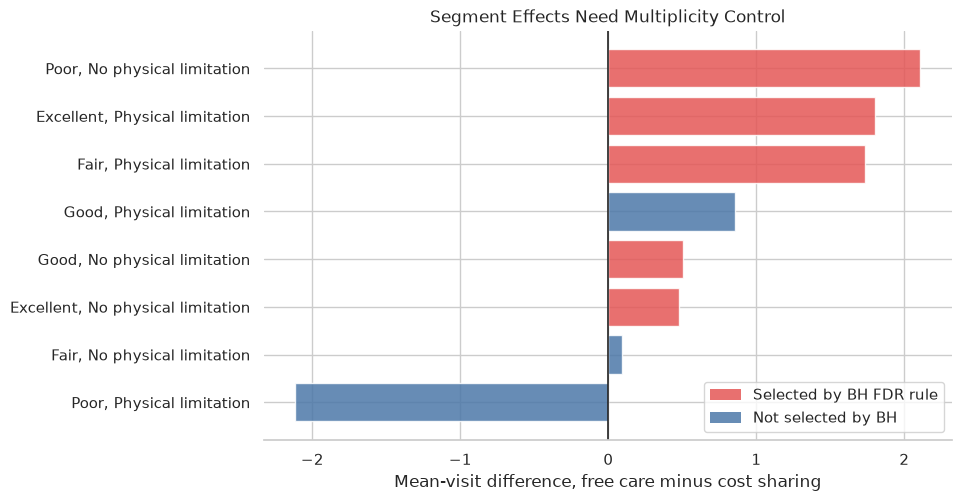

In [6]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from statsmodels.stats.multitest import multipletests


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rand_hie = load_statsmodels_randhie().copy()
    rand_hie["coinsurance"] = np.expm1(rand_hie["lncoins"]).round().clip(0, 100)
    rand_hie["free_care"] = rand_hie["coinsurance"].eq(0).astype(int)
    rand_hie["health_status"] = np.select(
        [rand_hie["hlthp"].eq(1), rand_hie["hlthf"].eq(1), rand_hie["hlthg"].eq(1)],
        ["Poor", "Fair", "Good"],
        default="Excellent",
    )
    rand_hie["limitation_group"] = np.where(rand_hie["physlm"].eq(1), "Physical limitation", "No physical limitation")

    rows = []
    for health_status in ["Excellent", "Good", "Fair", "Poor"]:
        for limitation_group in ["No physical limitation", "Physical limitation"]:
            segment = rand_hie.query("health_status == @health_status and limitation_group == @limitation_group")
            if segment["free_care"].nunique() < 2 or len(segment) < 80:
                continue
            free = segment.loc[segment["free_care"].eq(1), "mdvis"]
            cost = segment.loc[segment["free_care"].eq(0), "mdvis"]
            test = stats.ttest_ind(free, cost, equal_var=False)
            rows.append(
                {
                    "segment": f"{health_status}, {limitation_group}",
                    "n": len(segment),
                    "difference": free.mean() - cost.mean(),
                    "raw_p_value": test.pvalue,
                }
            )

    segment_tests = pd.DataFrame(rows).sort_values("raw_p_value")
    reject_bh, q_values, _, _ = multipletests(segment_tests["raw_p_value"], method="fdr_bh")
    reject_bonf, bonf_p, _, _ = multipletests(segment_tests["raw_p_value"], method="bonferroni")
    segment_tests["bh_q_value"] = q_values
    segment_tests["bh_selected"] = reject_bh
    segment_tests["bonferroni_selected"] = reject_bonf
    smart_display(segment_tests.round(4))

    fig, ax = plt.subplots(figsize=(9.5, 4.9), constrained_layout=True)
    plot_df = segment_tests.sort_values("difference")
    colors = np.where(plot_df["bh_selected"], "#E45756", "#4C78A8")
    ax.barh(plot_df["segment"], plot_df["difference"], color=colors, alpha=0.85)
    ax.axvline(0, color="#222222", linewidth=1.2)
    ax.set_title("Segment Effects Need Multiplicity Control")
    ax.set_xlabel("Mean-visit difference, free care minus cost sharing")
    ax.set_ylabel("")
    legend_handles = [
        Patch(facecolor="#E45756", edgecolor="none", alpha=0.85, label="Selected by BH FDR rule"),
        Patch(facecolor="#4C78A8", edgecolor="none", alpha=0.85, label="Not selected by BH"),
    ]
    ax.legend(handles=legend_handles, frameon=True, loc="lower right")
    sns.despine(fig=fig, left=True)
    plt.show()
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
The table and plot make the reporting lesson visible. Segment analyses can be useful, but the family of tests must be named before the strongest slice is highlighted. Otherwise the analysis quietly turns exploration into confirmation.

The red bars mark segments selected by the BH false-discovery-rate rule, not segments that are guaranteed to be true effects. The blue bars are still informative descriptively, but they should not be promoted as confirmed segment findings from this search. A professional report would state the family, the adjustment rule, and the follow-up plan before using these subgroup results to guide policy or product decisions.

## 6. What to Remember

1. The error rate attached to a single test does not automatically describe the risk of a whole dashboard of tests.
2. With many unadjusted tests, the chance of at least one false positive can become very large even when every null is true.
3. FWER control asks for protection against **any** false rejection in the family.
4. FDR control asks for a low **proportion** of false rejections among all rejections.
5. Bonferroni is simple and conservative; Holm is usually a better FWER default; BH is often more powerful for discovery work.
6. A method with valid long-run control can still produce a false discovery in one realized dataset.
7. High-stakes confirmation and exploratory prioritization should usually not be reported as if they were the same inferential task.

The next notebook keeps several inferential questions in view at once, but changes the machinery: we move from general multiple testing to **linear models as inferential engines**.


## References

- Benjamini, Y. (2010). *Discovering the false discovery rate*. *Journal of the Royal Statistical Society: Series B (Statistical Methodology), 72*(4), 405-416. [https://doi.org/10.1111/j.1467-9868.2010.00746.x](https://doi.org/10.1111/j.1467-9868.2010.00746.x)
- Benjamini, Y., & Hochberg, Y. (1995). *Controlling the false discovery rate: A practical and powerful approach to multiple testing*. *Journal of the Royal Statistical Society: Series B (Statistical Methodology), 57*(1), 289-300. [https://doi.org/10.1111/j.2517-6161.1995.tb02031.x](https://doi.org/10.1111/j.2517-6161.1995.tb02031.x)
- Benjamini, Y., & Yekutieli, D. (2001). *The control of the false discovery rate in multiple testing under dependency*. *The Annals of Statistics, 29*(4). [https://doi.org/10.1214/aos/1013699998](https://doi.org/10.1214/aos/1013699998)
- Verhoeven, K. J. F., Simonsen, K. L., & McIntyre, L. M. (2005). *Implementing false discovery rate control: increasing your power*. *Oikos, 108*(3), 643-647. [https://doi.org/10.1111/j.0030-1299.2005.13727.x](https://doi.org/10.1111/j.0030-1299.2005.13727.x)
